In [1]:
import os
import pandas as pd
import numpy as np

In [2]:
amount_of_valid_rows = 12462

In [3]:

file_path = r'Craters.xlsm'
required_columns = ['Long', 'Lat', 'ID', 'Diameter', 'Depth', 'Rim Degradation', 'Terrace', 'Rim', 'HPR', 'Chains and Fissures', 'Floor', 'Lava', 'Ray', 'Local terrain']
columns_to_convert = ['ID', 'Terrace', 'Rim', 'HPR', 'Chains and Fissures', 'Floor', 'Lava', 'Ray', 'Local terrain']

if not os.path.isfile(file_path):
    raise FileNotFoundError(f"File not found: {file_path}. Please check the file path and try again.")

try: 
    df_raw = pd.read_excel(file_path, engine='openpyxl')
    print(f"File '{file_path}' read successfully with {df_raw.shape[0]} rows and {df_raw.shape[1]} columns\n")
except Exception as e:
    print(f"Error reading the Excel file: {e}")
    raise

df_raw = df_raw.head(amount_of_valid_rows).copy()

df_raw.drop(columns=['FID', 'Name_Eng', 'Name_Ru', 'Origin_Eng', 'Origin_Ru', 'Unnamed: 10', 'Unnamed: 11', 'Features'], errors='ignore', inplace=True)

missing_columns = [col for col in required_columns if col not in df_raw.columns]
if missing_columns:
    raise KeyError(f"The dataset must contain the following columns: {missing_columns}")


df_raw[columns_to_convert] = df_raw[columns_to_convert].apply(lambda col: pd.to_numeric(col, errors='coerce').fillna(pd.NA).astype('Int64'))

df_raw['Depth'] = pd.to_numeric(df_raw['Depth'], errors='coerce').abs()
df_raw['Diameter'] = pd.to_numeric(df_raw['Diameter'], errors='coerce').abs()

df_raw.loc[df_raw['ID'] == 10161, 'Depth'] = 3.93077307

File 'Craters.xlsm' read successfully with 12468 rows and 22 columns



In [4]:
df_raw.head()

,ID,Long,Lat,Diameter,Depth,Rim Degradation,Terrace,Rim,HPR,Chains and Fissures,Floor,Lava,Ray,Local terrain
0,1,-153.994003,-16.340200,59.644947,NaN,4,2,3,1,3,3,1,0,3
1,2,44.624100,-21.897100,25.411955,0.489750,4,2,2,3,1,3,1,0,3
2,3,31.520901,-23.617201,38.995685,2.356500,4,5,2,1,3,3,1,0,3
3,4,28.184401,-22.487400,26.391520,1.454500,4,2,2,1,1,3,2,0,3
4,5,8.595550,-25.771299,18.786073,0.230125,4,1,2,0,1,2,3,0,1


In [5]:
print(f"df_raw shape before nan delete in Depth and Diameter: {df_raw.shape[0]}")
df_raw = df_raw.dropna(subset=['Depth', 'Diameter'])
print(f"df_raw shape after nan delete in Depth and Diameter: {df_raw.shape[0]}")
df = df_raw.copy()

df_raw shape before nan delete in Depth and Diameter: 12462
df_raw shape after nan delete in Depth and Diameter: 12450


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12450 entries, 1 to 12461
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   12450 non-null  Int64  
 1   Long                 12450 non-null  float64
 2   Lat                  12450 non-null  float64
 3   Diameter             12450 non-null  float64
 4   Depth                12450 non-null  float64
 5   Rim Degradation      12450 non-null  object 
 6   Terrace              12352 non-null  Int64  
 7   Rim                  12352 non-null  Int64  
 8   HPR                  12352 non-null  Int64  
 9   Chains and Fissures  12352 non-null  Int64  
 10  Floor                12352 non-null  Int64  
 11  Lava                 12352 non-null  Int64  
 12  Ray                  12274 non-null  Int64  
 13  Local terrain        12352 non-null  Int64  
dtypes: Int64(9), float64(4), object(1)
memory usage: 1.5+ MB


In [7]:
# 1. Record the initial row count
initial_count = len(df)


df = df.apply(pd.to_numeric, errors='coerce')

rows_with_nan = df.isna().any(axis=1).sum()

# 4. Drop all rows that contain any NaN
df.dropna(how='any', inplace=True)

# 5. Reset the index after dropping
df.reset_index(drop=True, inplace=True)

# 6. Print the number of deleted rows and remaining rows
print(f"Removed {rows_with_nan} rows out of {initial_count} total.")
print(f"{len(df)} rows remaining.")


Removed 176 rows out of 12450 total.
12274 rows remaining.


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12274 entries, 0 to 12273
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   12274 non-null  Int64  
 1   Long                 12274 non-null  float64
 2   Lat                  12274 non-null  float64
 3   Diameter             12274 non-null  float64
 4   Depth                12274 non-null  float64
 5   Rim Degradation      12274 non-null  float64
 6   Terrace              12274 non-null  Int64  
 7   Rim                  12274 non-null  Int64  
 8   HPR                  12274 non-null  Int64  
 9   Chains and Fissures  12274 non-null  Int64  
 10  Floor                12274 non-null  Int64  
 11  Lava                 12274 non-null  Int64  
 12  Ray                  12274 non-null  Int64  
 13  Local terrain        12274 non-null  Int64  
dtypes: Int64(9), float64(5)
memory usage: 1.4 MB


# Разбиение на квадранты

In [9]:

# longitudes = df['Long'].values
# latitudes = df['Lat'].values


# longitudes_rad = np.radians(longitudes)
# latitudes_rad = np.radians(latitudes)

# df['Long_rad'] = longitudes_rad
# df['Lat_rad'] = latitudes_rad

# r = 1  # Assume unit sphere
# x = r * np.cos(latitudes_rad) * np.cos(longitudes_rad)
# y = r * np.cos(latitudes_rad) * np.sin(longitudes_rad)
# z = r * np.sin(latitudes_rad)

# df['x'] = x
# df['y'] = y
# df['z'] = z

# 1. Define a function to classify Mercury quadrant
def classify_mercury_quadrant(lat, lon):
    """
    Return the official USGS quadrangle (H-n name) for each crater on Mercury
    based on latitude and longitude.
    """
    if lon < 0:
        lon = lon + 360

    if 66 <= lat <= 90:
        return "H-3 Borealis"
    elif 21 <= lat < 66:
        if (288 <= lon <= 360) or (0 <= lon < 72):
            return "H-1 Kuiper"
        elif 216 <= lon < 288:
            return "H-2 Shakespeare"
        elif 144 <= lon < 216:
            return "H-4 Raditladi"
        elif 72 <= lon < 144:
            return "H-5 Eminescu"
        else:
            return "H-6 Hokusai"
    elif -21 <= lat < 21:
        if (288 <= lon <= 360) or (0 <= lon < 72):
            return "H-7 Beethoven"
        elif 216 <= lon < 288:
            return "H-8 Tolstoj"
        elif 144 <= lon < 216:
            return "H-9 Turgenev"
        elif 72 <= lon < 144:
            return "H-10 Derain"
        else:
            return "H-11 Neruda"
    elif -66 <= lat < -21:
        if (288 <= lon <= 360) or (0 <= lon < 72):
            return "H-12 Debussy"
        elif 216 <= lon < 288:
            return "H-13 Rembrandt"
        elif 144 <= lon < 216:
            return "H-14 Sanai"
        else:
            return "H-15 Bach"
    else:
        return "Unknown"

df["Mercury_Quadrant"] = df.apply(lambda row: classify_mercury_quadrant(row["Lat"], row["Long"]), axis=1)


df["Quadrant_Encoded"] = df["Mercury_Quadrant"].astype("category").cat.codes

print(df[["Lat", "Long", "Mercury_Quadrant", "Quadrant_Encoded"]].head())


nan_lat_long = df[['Lat', 'Long']].isna().sum()
df.drop(columns=['Long', 'Lat', 'Long_rad', 'Lat_rad', 'Features'], errors='ignore', inplace=True)
df.head()


         Lat       Long Mercury_Quadrant  Quadrant_Encoded
0 -21.897100  44.624100     H-12 Debussy                 2
1 -23.617201  31.520901     H-12 Debussy                 2
2 -22.487400  28.184401     H-12 Debussy                 2
3 -25.771299   8.595550     H-12 Debussy                 2
4 -28.808001  11.979200     H-12 Debussy                 2


,ID,Diameter,Depth,Rim Degradation,Terrace,Rim,HPR,Chains and Fissures,Floor,Lava,Ray,Local terrain,Mercury_Quadrant,Quadrant_Encoded
0,2,25.411955,0.489750,4.0,2,2,3,1,3,1,0,3,H-12 Debussy,2
1,3,38.995685,2.356500,4.0,5,2,1,3,3,1,0,3,H-12 Debussy,2
2,4,26.391520,1.454500,4.0,2,2,1,1,3,2,0,3,H-12 Debussy,2
3,5,18.786073,0.230125,4.0,1,2,0,1,2,3,0,1,H-12 Debussy,2
4,6,23.369064,0.313125,5.0,3,2,1,3,3,2,0,1,H-12 Debussy,2


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12274 entries, 0 to 12273
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   12274 non-null  Int64  
 1   Diameter             12274 non-null  float64
 2   Depth                12274 non-null  float64
 3   Rim Degradation      12274 non-null  float64
 4   Terrace              12274 non-null  Int64  
 5   Rim                  12274 non-null  Int64  
 6   HPR                  12274 non-null  Int64  
 7   Chains and Fissures  12274 non-null  Int64  
 8   Floor                12274 non-null  Int64  
 9   Lava                 12274 non-null  Int64  
 10  Ray                  12274 non-null  Int64  
 11  Local terrain        12274 non-null  Int64  
 12  Mercury_Quadrant     12274 non-null  object 
 13  Quadrant_Encoded     12274 non-null  int8   
dtypes: Int64(9), float64(3), int8(1), object(1)
memory usage: 1.3+ MB


# Анализ корреляции признаков (только категориальные)

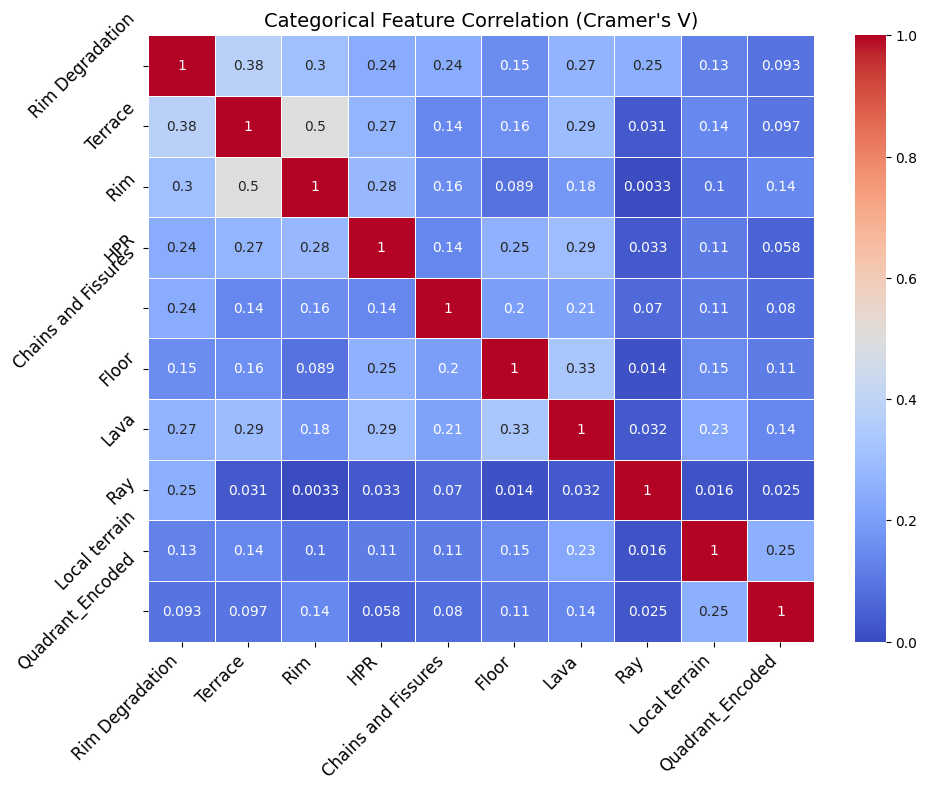

In [11]:
import numpy as np
import scipy.stats as ss
from sklearn.metrics import mutual_info_score
import matplotlib.pyplot as plt
import seaborn as sns

def cramers_v(x, y):
    """
    Compute Cramer's V statistic for two categorical variables.
    """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

categorical_columns = [
    "Rim Degradation", #убрать
    "Terrace", #убрать
    "Rim",
    "HPR",
    "Chains and Fissures",
    "Floor", #убрать
    "Lava",
    "Ray",
    "Local terrain",
    "Quadrant_Encoded"
]

cat_corr_matrix = pd.DataFrame(index=categorical_columns, columns=categorical_columns)

for col1 in categorical_columns:
    for col2 in categorical_columns:
        cat_corr_matrix.loc[col1, col2] = cramers_v(df[col1], df[col2])

cat_corr_matrix = cat_corr_matrix.astype(float)
np.fill_diagonal(cat_corr_matrix.values, 1.0)

plt.figure(figsize=(10, 8))
sns.heatmap(cat_corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, linewidths=0.5)

plt.title("Categorical Feature Correlation (Cramer's V)", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=45, fontsize=12)

plt.tight_layout()
plt.show()


In [12]:
df.drop(columns=[
    'Rim Degradation', 
    'Floor', 
    'Terrace',
    # 'Local terrain', 
    # 'Quadrant_Encoded', 
    'Mercury_Quadrant'],
    errors='ignore', inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12274 entries, 0 to 12273
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   12274 non-null  Int64  
 1   Diameter             12274 non-null  float64
 2   Depth                12274 non-null  float64
 3   Rim                  12274 non-null  Int64  
 4   HPR                  12274 non-null  Int64  
 5   Chains and Fissures  12274 non-null  Int64  
 6   Lava                 12274 non-null  Int64  
 7   Ray                  12274 non-null  Int64  
 8   Local terrain        12274 non-null  Int64  
 9   Quadrant_Encoded     12274 non-null  int8   
dtypes: Int64(7), float64(2), int8(1)
memory usage: 959.0 KB


# Снижение размерности, кластеризация и маппер

In [ ]:
import pandas as pd
import kmapper as km
from sklearn.cluster import DBSCAN
from prince import FAMD  # Если ваши данные содержат и числовые, и категориальные признаки

# Предполагается, что DataFrame df уже определён
# features = df.drop("ID", axis=1)

features = df.drop("ID", axis=1)  # Replace this with df.drop("ID", axis=1) if necessary
features_for_lens = df.drop(columns=['Depth', 'Diameter', 'HPR', 'ID'])

# Для lens можно использовать все признаки, либо отфильтровать ненужные
# Здесь мы используем FAMD для проекции:
# famd = FAMD(n_components=3, random_state=42)
# lens_data = famd.fit_transform(features)

# Настройка Mapper:
mapper = km.KeplerMapper(verbose=1)

# Настройка кластеризации (DBSCAN)
clusterer = DBSCAN(eps=5, min_samples=3)

# Настройка покрытия с уменьшенным числом кубов и увеличенным перекрытием
cover = km.Cover(n_cubes=3, perc_overlap=0.4)

# Построение Mapper-графа
graph = mapper.map(
    lens=features_for_lens,
    X=features,
    clusterer=clusterer,
    cover=cover
)

print("Общее количество кластеров (вершин):", len(graph["nodes"]))
for node, indices in graph["nodes"].items():
    cluster_ids = df.iloc[indices]['ID'].tolist()
    print(f"Кластер {node} содержит ID: {cluster_ids}")

# Итоговое число элементов до объединения кластеров (узлов)
num_clusters = sum(len(val) for val in graph["nodes"].values())
print(f"Итого кластеров до объединения узлов: {num_clusters}")

# Функция для дедупликации графа (если требуется)
def deduplicate_mapper_graph(graph):
    unique_nodes = {}
    for node, indices in graph["nodes"].items():
        key = tuple(sorted(indices))
        if key not in unique_nodes:
            unique_nodes[key] = node

    new_nodes = {node: list(key) for key, node in unique_nodes.items()}

    new_links = {}
    for node, linked_nodes in graph.get("links", {}).items():
        if node in new_nodes:
            new_links[node] = [n for n in linked_nodes if n in new_nodes]
    
    graph["nodes"] = new_nodes
    if "links" in graph:
        graph["links"] = new_links
    
    return graph

graph = deduplicate_mapper_graph(graph)

# Сохранение визуализации в HTML с перенаправлением вывода в файл:
from contextlib import redirect_stdout
import io

f = io.StringIO()
with redirect_stdout(f):
    mapper.visualize(
        graph,
        path_html="kepler_mapper_output.html",
        title="KeplerMapper Graph с FAMD и DBSCAN"
    )


KeplerMapper(verbose=1)
Mapping on data shaped (12274, 9) using lens shaped (12274, 3)

Creating 27 hypercubes.

Created 627 edges and 146 nodes in 0:00:01.037637.
Общее количество кластеров (вершин): 146
Кластер cube0_cluster0 содержит ID: [70, 78, 79, 123, 124, 150, 151, 152, 163, 164, 166, 167, 168, 170, 172, 175, 198, 260, 268, 269, 278, 284, 285, 288, 296, 298, 300, 301, 337, 393, 404, 413, 436, 549, 695, 879, 885, 888, 889, 1044, 1162, 1175, 1177, 1178, 1179, 1180, 1188, 1189, 1190, 1193, 1247, 1253, 1378, 1399, 1405, 1412, 1424, 1427, 1430, 1439, 1442, 1450, 1461, 1463, 1466, 1558, 1567, 1571, 1577, 1578, 1581, 1588, 1592, 1607, 1610, 1612, 1712, 1800, 1817, 1821, 1828, 1832, 1835, 1918, 2040, 2054, 2056, 2096, 2107, 2119, 2150, 2153, 2154, 2164, 2171, 2172, 2175, 2177, 2181, 2183, 2329, 2355, 2384, 2402, 2407, 2415, 2416, 2417, 2418, 2419, 2420, 2421, 2425, 2426, 2428, 2429, 2430, 2431, 2441, 2442, 2447, 2448, 2454, 2456, 2457, 2460, 2467, 2469, 2471, 2472, 2477, 2478, 2481, 24

# Сохранение выбранного кластера/графа

In [15]:
selected_cluster = "cube397_cluster3"

# Set the flag:
# If False, return only the IDs from the selected cluster.
# If True, return IDs from the entire connected component (all clusters reachable via edges).
entire_graph_flag = True  # or False

def get_connected_component(selected_node, links):
    visited = set()
    stack = [selected_node]
    while stack:
        current = stack.pop()
        if current not in visited:
            visited.add(current)
            for neighbor in links.get(current, []):
                if neighbor not in visited:
                    stack.append(neighbor)
    return visited

id_frequency = {}
for node, indices in graph["nodes"].items():
    sample_ids = [df.iloc[i]["ID"] for i in indices]
    for sid in sample_ids:
        id_frequency[sid] = id_frequency.get(sid, 0) + 1

if not entire_graph_flag:
    nodes_to_consider = {selected_cluster}
else:
    nodes_to_consider = get_connected_component(selected_cluster, graph.get("links", {}))

selected_ids = set()
for node in nodes_to_consider:
    if node in graph["nodes"]:
        sample_ids = [df.iloc[i]["ID"] for i in graph["nodes"][node]]
        selected_ids.update(sample_ids)
    else:
        print(f"Warning: Node {node} not found in graph nodes.")

result = []
for sid in selected_ids:
    if id_frequency.get(sid, 0) == 1:
        found_cluster = None
        for node in nodes_to_consider:
            if node in graph["nodes"]:
                sample_ids = [df.iloc[i]["ID"] for i in graph["nodes"][node]]
                if sid in sample_ids:
                    found_cluster = node
                    break
        result.append({"ID": sid, "type": found_cluster if found_cluster else "unknown"})
    else:
        result.append({"ID": sid, "type": "edge"})

result = sorted(result, key=lambda x: x["ID"])

print("Selected sample IDs with their cluster assignment (for core samples) or 'edge':")
for entry in result:
    print(entry)

result_df = pd.DataFrame(result)
# print(result_df)

Selected sample IDs with their cluster assignment (for core samples) or 'edge':


In [16]:
# result_df['ID'].apply(lambda x: int(x))
folder_path = r"mercury"
csv_filename = "clusters.csv"
csv_path = os.path.join(folder_path, csv_filename)

result_df.to_csv(csv_path, index=False)
print(f"Clusters dataframe saved to: {csv_path}")

result_df.head(10)

Clusters dataframe saved to: mercury/clusters.csv


""


In [17]:
result_df.shape[0]

0

In [18]:
result_df['type'].unique()

KeyError: 'type'